# Supply Chain Performance Analysis — DataCo Dataset

## Objective
Perform Exploratory Data Analysis (EDA) on the DataCo Supply Chain dataset to identify data quality issues, clean and transform data, create new features, generate KPIs, and visualize business insights.

## Import Required Libraries

In [ ]:
# This step imports all necessary Python libraries such as pandas, numpy, matplotlib for data analysis and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Dataset

In [ ]:
# In this step, the DataCo Supply Chain dataset is loaded into a pandas DataFrame for further analysis.
Dataset = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")

Dataset.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


## Dataset Overview

In [ ]:
# Display dataset shape
print("Dataset Shape:", Dataset.shape)

Dataset Shape: (13920, 53)


In [ ]:
# Display column names
print("Column Names:")
print(Dataset.columns)

Column Names:
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
    

In [ ]:
# Display data types
print("Dataset Info:")
Dataset.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13920 entries, 0 to 13919
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           13920 non-null  object 
 1   Days for shipping (real)       13920 non-null  int64  
 2   Days for shipment (scheduled)  13920 non-null  int64  
 3   Benefit per order              13920 non-null  float64
 4   Sales per customer             13920 non-null  float64
 5   Delivery Status                13920 non-null  object 
 6   Late_delivery_risk             13920 non-null  int64  
 7   Category Id                    13920 non-null  int64  
 8   Category Name                  13920 non-null  object 
 9   Customer City                  13920 non-null  object 
 10  Customer Country               13920 non-null  object 
 11  Customer Email                 13920 non-null  object 
 12  Customer Fname                 1

## Descriptive Statistics

In [ ]:
# Generate summary statistics such as count, mean, standard deviation, minimum, and maximum values for numerical columns.
print("Descriptive Statistics:")
Dataset.describe()

Descriptive Statistics:


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,13920.000000,13920.000000,13920.000000,13920.000000,13920.000000,13920.000000,13920.000000,13919.000000,13919.000000,13919.000000,...,13919.000000,13919.000000,13919.000000,13919.000000,1636.000000,13919.000000,13919.000000,0.0,13919.000000,13919.0
mean,3.702586,3.161063,21.313542,182.722125,0.530101,26.143032,7014.956968,27219.253969,4.626051,26.837019,...,2.454127,203.701785,182.728702,21.312126,55106.169315,556.319851,26.142252,NaN,122.884987,0.0
std,1.532105,1.211130,113.847419,128.518919,0.499111,16.225024,4464.173700,36108.222532,1.609280,9.792209,...,1.575390,142.934050,128.521193,113.851386,31725.488488,331.033146,16.225346,NaN,141.382399,0.0
min,0.000000,0.000000,-3366.000000,8.470000,0.000000,2.000000,1.000000,603.000000,2.000000,17.982491,...,1.000000,11.290000,8.470000,-3366.000000,1453.000000,19.000000,2.000000,NaN,11.290000,0.0
25%,2.000000,2.000000,6.810000,100.000000,0.000000,17.000000,3406.750000,725.000000,4.000000,18.246456,...,1.000000,119.980003,100.000000,6.810000,24153.000000,365.000000,17.000000,NaN,50.000000,0.0
50%,4.000000,4.000000,30.580000,151.169998,1.000000,24.000000,6737.000000,725.000000,4.000000,18.296520,...,2.000000,179.970001,151.169998,30.570000,60020.500000,502.000000,24.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.052502,251.979996,1.000000,29.000000,10074.500000,60418.500000,5.000000,36.163929,...,4.000000,299.950012,251.979996,64.055000,90004.000000,627.000000,29.000000,NaN,129.990005,0.0
max,6.000000,4.000000,684.000000,1759.989990,1.000000,76.000000,20755.000000,98632.000000,12.000000,48.781933,...,5.000000,1999.989990,1759.989990,684.000000,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


## Data Attribute Classification — Dimensions vs Measures

In [ ]:
# Classify dataset columns into:
# Dimensions → describes data (who/what/where)
# Measures → numerical values used for calculations

dimensions = []
measures = []

dimension_numerical_cols = [
    'Category Id','Customer Id','Order Customer Id','Department Id',
    'Order Id','Order Item Id','Order Item Cardprod Id','Product Card Id',
    'Product Category Id','Customer Zipcode','Order Zipcode',
    'Product Status','Latitude','Longitude'
]

for col in Dataset.columns:
    if Dataset[col].dtype == 'object' or Dataset[col].dtype == 'bool' or col in dimension_numerical_cols:
        dimensions.append(col)
    else:
        measures.append(col)

# Move special cases manually
if 'Late_delivery_risk' in dimensions:
    dimensions.remove('Late_delivery_risk')
    measures.append('Late_delivery_risk')

print("Dimensions:")
print(dimensions)

print("\nMeasures:")
print(measures)

Dimensions:
['Type', 'Delivery Status', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']

Measures:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per O

## EDA - Cleaning and Transformation

### Subtask:
Perform Exploratory Data Analysis (EDA) to identify and address data quality issues. This includes checking for missing values, handling potential duplicates, correcting inconsistent data entries, and transforming columns to appropriate data types (e.g., converting 'Year' to datetime if applicable, numerical columns to integers/floats). I will document any transformations made.

## Checking Missing Values

In [ ]:
# Identify missing or null values in the dataset to detect data quality issues.
print("Missing Values Count:")
Dataset.isnull().sum()

Missing Values Count:


,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


## Handling Missing Values

In [ ]:
Dataset.drop(columns=['Product Description'], inplace=True)

In [ ]:
# Fill numeric columns with mean
num_cols = Dataset.select_dtypes(include=['int64','float64']).columns
Dataset[num_cols] = Dataset[num_cols].fillna(Dataset[num_cols].mean())

# Fill categorical columns with mode
cat_cols = Dataset.select_dtypes(include='object').columns
for col in cat_cols:
    Dataset[col] = Dataset[col].fillna(Dataset[col].mode()[0])

print("Missing values after cleaning:")
print(Dataset.isnull().sum())

Missing values after cleaning:
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Email                   0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Password                0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id       

## Removing Duplicate Records

In [ ]:
# Remove duplicate rows to ensure data consistency and avoid repeated entries.
print("Duplicate rows:", Dataset.duplicated().sum())

Dataset = Dataset.drop_duplicates()

Duplicate rows: 0


## Cleaning Column Names

In [ ]:
# Standardize column names by removing spaces and converting them to lowercase for easier access and consistency.
Dataset.columns = Dataset.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned column names:")
print(Dataset.columns)

Cleaned column names:
Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_password', 'customer_segment',
       'customer_state', 'customer_street', 'customer_zipcode',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id',
       'order_date_(dateorders)', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'order_zipcode', 'product_card_id', 'product_category_i

## Date Transformation

In [ ]:
# Convert order date to datetime
if 'order_date_(dateorders)' in Dataset.columns:
    Dataset['order_date_(dateorders)'] = pd.to_datetime(
        Dataset['order_date_(dateorders)'], errors='coerce'
    )

    Dataset['order_year'] = Dataset['order_date_(dateorders)'].dt.year
    Dataset['order_month'] = Dataset['order_date_(dateorders)'].dt.month

print('order_year' in Dataset.columns)
print('order_month' in Dataset.columns)

print("Date transformation completed")

True
True
Date transformation completed


## Feature Engineering

In [ ]:
# Create new features to improve analysis:
# - Profit Margin
# - Delivery Delay

# Profit margin
if 'order_profit_per_order' in Dataset.columns and 'sales' in Dataset.columns:
    Dataset['profit_margin'] = Dataset['order_profit_per_order'] / Dataset['sales']

# Delivery delay
if 'days_for_shipping_(real)' in Dataset.columns and 'days_for_shipment_(scheduled)' in Dataset.columns:
    Dataset['delivery_delay'] = (
        Dataset['days_for_shipping_(real)'] - Dataset['days_for_shipment_(scheduled)']
    )

print("New features created")
Dataset.head()

New features created


,type,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_image,product_name,product_price,product_status,shipping_date_(dateorders),shipping_mode,order_year,order_month,profit_margin,delivery_delay
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class,2018,1,0.278413,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class,2018,1,-0.760000,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class,2018,1,-0.756003,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class,2018,1,0.069748,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class,2018,1,0.409489,-2


## Key Performance Indicators (KPIs)



Calculate important business metrics such as:
- Total Sales
- Total Profit
- Average Shipping Time
- Late Delivery Rate

In [ ]:
# Calculate important business metrics such as:
# Total Sales, Total Profit, Average Shipping Time, Late Delivery Rate

print("----- Key Performance Indicators -----")

if 'sales' in Dataset.columns:
    print("Total Sales:", Dataset['sales'].sum())

if 'order_profit_per_order' in Dataset.columns:
    print("Total Profit:", Dataset['order_profit_per_order'].sum())

if 'days_for_shipping_(real)' in Dataset.columns:
    print("Average Shipping Days:", Dataset['days_for_shipping_(real)'].mean())

if 'late_delivery_risk' in Dataset.columns:
    print("Late Delivery Rate:", Dataset['late_delivery_risk'].mean())

----- Key Performance Indicators -----
Total Sales: 2835528.8524259254
Total Profit: 296664.7925457533
Average Shipping Days: 3.7025862068965516
Late Delivery Rate: 0.5301005747126437


## Data Visualization

Visualize supply chain performance using charts and graphs to identify patterns and trends.


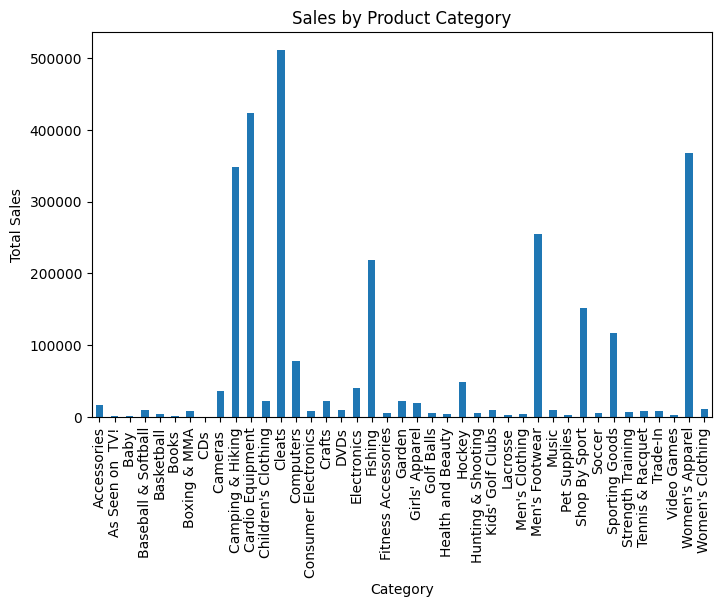

In [ ]:
# Sales by Product Category
# Analyze total sales distribution across different product categories.
# Bar Chart

if 'category_name' in Dataset.columns:
    sales_by_category = Dataset.groupby('category_name')['sales'].sum()

    plt.figure(figsize=(8,5))
    sales_by_category.plot(kind='bar')
    plt.title("Sales by Product Category")
    plt.xlabel("Category")
    plt.ylabel("Total Sales")
    plt.show()

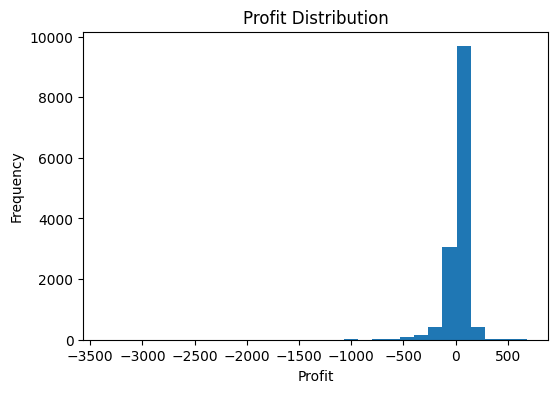

In [ ]:
# Profit Distribution
# Visualize profit distribution to understand variation in order profits.
# Histogram

if 'order_profit_per_order' in Dataset.columns:
    plt.figure(figsize=(6,4))
    plt.hist(Dataset['order_profit_per_order'], bins=30)
    plt.title("Profit Distribution")
    plt.xlabel("Profit")
    plt.ylabel("Frequency")
    plt.show()

Most orders give very small profit.
Some orders are giving loss.

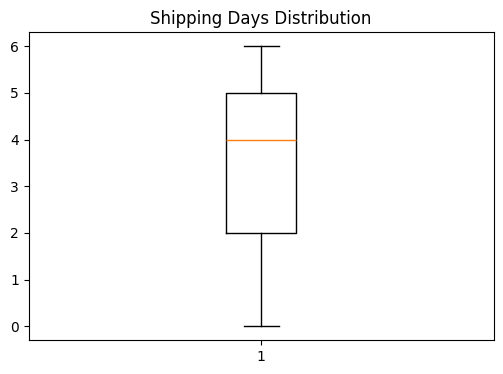

In [ ]:
# Shipping Time Analysis
# Analyze distribution of shipping days to evaluate delivery performance.
# boxplot

if 'days_for_shipping_(real)' in Dataset.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(Dataset['days_for_shipping_(real)'])
    plt.title("Shipping Days Distribution")
    plt.show()

Median shipping time ≈ 4 days

Majority deliveries happen between 2-5 days

Minimum delivery = 0 days, maximum = 6 days

No major outliers (no extreme delays)

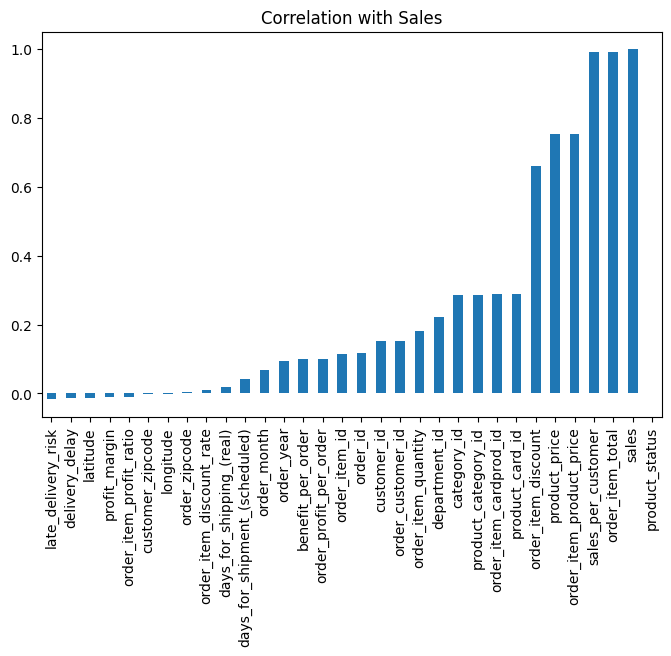

In [ ]:
# Correlation of all numeric columns with Sales
corr = Dataset.select_dtypes(include='number').corr()['sales'].sort_values()

plt.figure(figsize=(8,5))
corr.plot(kind='bar')
plt.title("Correlation with Sales")
plt.show()

The correlation analysis shows that order value, product status, sales per customer, and pricing factors strongly influence sales, while delivery-related factors have minimal impact.

In [ ]:
print("Final Dataset Info:")
Dataset.info()

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13920 entries, 0 to 13919
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   type                           13920 non-null  object        
 1   days_for_shipping_(real)       13920 non-null  int64         
 2   days_for_shipment_(scheduled)  13920 non-null  int64         
 3   benefit_per_order              13920 non-null  float64       
 4   sales_per_customer             13920 non-null  float64       
 5   delivery_status                13920 non-null  object        
 6   late_delivery_risk             13920 non-null  int64         
 7   category_id                    13920 non-null  int64         
 8   category_name                  13920 non-null  object        
 9   customer_city                  13920 non-null  object        
 10  customer_country               13920 non-null  object        


In [ ]:
Dataset

,type,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_image,product_name,product_price,product_status,shipping_date_(dateorders),shipping_mode,order_year,order_month,profit_margin,delivery_delay
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,2/3/2018 22:56,Standard Class,2018,1,0.278413,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/18/2018 12:27,Standard Class,2018,1,-0.760000,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/17/2018 12:06,Standard Class,2018,1,-0.756003,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/16/2018 11:45,Standard Class,2018,1,0.069748,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/15/2018 11:24,Standard Class,2018,1,0.409489,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13915,DEBIT,3,4,49.200001,120.000000,Advance shipping,0,24,Women's Apparel,Philadelphia,...,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0.0,8/18/2015 8:26,Standard Class,2015,8,0.328000,-1
13916,DEBIT,6,4,15.000000,120.000000,Late delivery,1,24,Women's Apparel,New York,...,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0.0,10/27/2015 9:34,Standard Class,2015,10,0.100000,2
13917,DEBIT,5,4,-37.790001,89.980003,Late delivery,1,29,Shop By Sport,Washington,...,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0.0,7/3/2017 8:00,Standard Class,2017,6,-0.314995,1
13918,DEBIT,4,4,11.890000,71.220001,Shipping on time,0,40,Accessories,Brooklyn,...,http://images.acmesports.sports/Team+Golf+St.+...,Team Golf St. Louis Cardinals Putter Grip,24.990000,0.0,1/3/2017 11:25,Standard Class,2016,12,0.158597,0


In [ ]:
Dataset.to_csv("cleaned_dataset.csv", index=False)

## Conclusion

- Performed data cleaning and transformation.
- Handled missing values and duplicates.
- Created new features like profit margin and delivery delay.
- Generated key performance indicators.
- Visualized supply chain performance trends.

The dataset is now ready for further analysis.